In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [56]:
# sample source data
somaMeta = pd.read_csv('../data/GNPC_Harmonized_Dataset_V1/SomalogicMetaV1_anonymized.csv')
somaMeta.head()

/tmp/ipykernel_2846197/3545570142.py:2: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  somaMeta = pd.read_csv('../data/GNPC_Harmonized_Dataset_V1/SomalogicMetaV1_anonymized.csv')


,sample_id,contributor_code,visit,plate_id,units,anml_fraction_used_0_005,anml_fraction_used_0_5,anml_fraction_used_20,anml_fraction_used_20_s1,anml_fraction_used_20_s2,...,hyb_control_norm_scale,norm_scale_0_005,norm_scale_0_5,norm_scale_20,norm_scale_20_s1,norm_scale_20_s2,norm_scale_20_s3,row_check,sample_matrix,sample_type
0,8a0e5419-20f3-44d6-bb46-bab165bf8d05,R,1,147,-1,0.866,0.836,0.847,-1.0,-1.0,...,0.934112,1.435652,0.824065,0.722277,-1.0,-1.0,-1.0,PASS,EDTA Plasma,Sample
1,1f2178f2-83a6-46df-aec1-3dd741621068,R,2,147,-1,0.936,0.947,0.954,-1.0,-1.0,...,0.884058,0.894184,0.804804,0.841661,-1.0,-1.0,-1.0,PASS,EDTA Plasma,Sample
2,40c3925c-a770-4adc-9a87-5d9e2a23b855,R,1,147,-1,0.973,0.939,0.913,-1.0,-1.0,...,0.906697,1.100648,1.043171,0.901319,-1.0,-1.0,-1.0,PASS,EDTA Plasma,Sample
3,9de3c941-b32b-4ef8-8d59-6b57b905c657,R,2,147,-1,0.888,0.843,0.859,-1.0,-1.0,...,0.994137,1.165921,0.942466,0.825704,-1.0,-1.0,-1.0,PASS,EDTA Plasma,Sample
4,03830809-3976-4f58-8279-ca2ffd0398c4,R,2,147,-1,0.850,0.828,0.804,-1.0,-1.0,...,0.925489,1.061411,0.659705,0.608147,-1.0,-1.0,-1.0,PASS,EDTA Plasma,Sample


In [57]:
somaAnaly = pd.read_csv('../data/GNPC_Harmonized_Dataset_V1/SomalogicAnalyteInfoV1_anonymized.csv')
somaAnaly.head()

,table_name,column_name,apt_name,seq_id,seq_id_version,soma_id,target_full_name,target,uni_prot,entrez_gene_id,entrez_gene_symbol,organism,units,type
0,Somalogic01V1_4ta,seq_10003_15,seq.10003.15,10003-15,3,SL019245,Zinc finger protein 41,ZNF41,P51814,7592,ZNF41,Human,RFU,Protein
1,Somalogic01V1_4ta,seq_10006_25,seq.10006.25,10006-25,3,SL019228,ETS domain-containing protein Elk-1,ELK1,P19419,2002,ELK1,Human,RFU,Protein
2,Somalogic01V1_4ta,seq_10008_43,seq.10008.43,10008-43,3,SL019234,Guanylyl cyclase-activating protein 1,GUC1A,P43080,2978,GUCA1A,Human,RFU,Protein
3,Somalogic01V1_4ta,seq_10010_10,seq.10010.10,10010-10,3,SL014943,Beclin-1,BECN1,Q14457,8678,BECN1,Human,RFU,Protein
4,Somalogic01V1_4ta,seq_10011_65,seq.10011.65,10011-65,3,SL019246,Inositol polyphosphate 5-phosphatase OCRL-1,OCRL,Q01968,4952,OCRL,Human,RFU,Protein


In [58]:
# sample data files
somaData = {}
indices = ["01", "02", "03", "04", "05", "06", "07", "08", "09", "10", "11", "12"]
for i in indices:
    file = f"../data/GNPC_Harmonized_Dataset_V1/Somalogic{i}V1_anonymized.csv"
    try:
        df = pd.read_csv(file, encoding="utf-8", engine="python")
    except:
        df = pd.read_csv(file, encoding="latin1", engine="python")

    somaData[i] = df

In [59]:
# Separate different sample matrices into different dataframes
somaGroups = {key: subdf for key, subdf in somaMeta.groupby("sample_matrix")}


In [60]:
# Extract sample data of a specific matrix type
def get_data_by_matrix_type(matrix_type, groups, somaData):
    if matrix_type not in groups:
        raise ValueError(f"Matrix type {matrix_type} not found in metadata.")
    
    sample_ids = groups[matrix_type]['sample_id'].tolist()
    data_frames = {}
    
    for idx, df in somaData.items():
        filtered_df = df[df['sample_id'].isin(sample_ids)]
        data_frames[idx] = filtered_df
    
    return data_frames


In [61]:
def group_by_missing_values(somaSpec):
    groups = {}
    for idx, df in somaSpec.items():
        mask = (df == -1)
        n_missing = mask.sum(axis=1)

        pattern = mask.apply(tuple, axis=1)   # exact missing pattern (True/False per column)

        # For each missing count: True if only 1 pattern, False if multiple
        grouped_patterns = pattern.groupby(n_missing)
        pattern_counts = grouped_patterns.nunique()
        unique_pattern = (pattern_counts == 1).all()
        inconsistent = {}
        if not unique_pattern:
            inconsistent = pattern_counts[pattern_counts != 1].to_dict()
            print(f"Warning: Missing values are scattered among different columns for some missing counts in data file {idx}, further splitting by missing patterns.")
        else:
            print(f"Checked: Missing values exist in consistent columns for each missing count in data file {idx}, showing that missing value is due to different somascan types.")

        # Group by number of missing values
        groups[idx] = {f"missing_{count}": subdf
            for count, subdf in df.groupby(n_missing) if count not in inconsistent
        }
        for count in inconsistent.keys():
            for p_idx, pat in enumerate(grouped_patterns.get_group(count).drop_duplicates()):
                groups[idx][f"missing_{count}_pattern_{p_idx}"] = df[pattern == pat]

    return groups

In [62]:
somaSpec3 = get_data_by_matrix_type('CSF', somaGroups, somaData)
missing_groups3 = group_by_missing_values(somaSpec3)
for idx, df in missing_groups3.items():
    print(f"DataFrame {idx} grouped by missing values:")
    for missing_count, group in df.items():
        print(f"  Missing values: {missing_count}, Number of samples: {len(group)}")


Checked: Missing values exist in consistent columns for each missing count in data file 01, showing that missing value is due to different somascan types.
Checked: Missing values exist in consistent columns for each missing count in data file 02, showing that missing value is due to different somascan types.
Checked: Missing values exist in consistent columns for each missing count in data file 03, showing that missing value is due to different somascan types.
Checked: Missing values exist in consistent columns for each missing count in data file 04, showing that missing value is due to different somascan types.
Checked: Missing values exist in consistent columns for each missing count in data file 05, showing that missing value is due to different somascan types.
Checked: Missing values exist in consistent columns for each missing count in data file 06, showing that missing value is due to different somascan types.
Checked: Missing values exist in consistent columns for each missing c

In [63]:
scan3_3k = {"01": pd.concat([missing_groups3["01"]["missing_1"], missing_groups3["01"]["missing_2"]], ignore_index=True),
            "02": missing_groups3["02"]["missing_0"],
            "03": missing_groups3["03"]["missing_174"],
            "04": missing_groups3["04"]["missing_650"],
            "05": missing_groups3["05"]["missing_650"],
            "06": missing_groups3["06"]["missing_641"],
            "07": missing_groups3["07"]["missing_629"],
            "08": missing_groups3["08"]["missing_165"],
            "09": missing_groups3["09"]["missing_35"],
            "10": missing_groups3["10"]["missing_0"],
            "11": missing_groups3["11"]["missing_14"],
            "12": missing_groups3["12"]["missing_1"]}
scan3_5k = {"01": missing_groups3["01"]["missing_90"],
            "02": missing_groups3["02"]["missing_35"],
            "03": missing_groups3["03"]["missing_80"],
            "04": missing_groups3["04"]["missing_12"],
            "05": missing_groups3["05"]["missing_396"],
            "06": missing_groups3["06"]["missing_633"],
            "07": missing_groups3["07"]["missing_631"],
            "08": missing_groups3["08"]["missing_221"],
            "09": missing_groups3["09"]["missing_103"],
            "10": missing_groups3["10"]["missing_89"],
            "11": missing_groups3["11"]["missing_93"],
            "12": missing_groups3["12"]["missing_78"]}
scan3_7k = {"01": missing_groups3["01"]["missing_24"],
            "02": missing_groups3["02"]["missing_6"],
            "03": missing_groups3["03"]["missing_12"],
            "04": missing_groups3["04"]["missing_0"],
            "05": missing_groups3["05"]["missing_0"],
            "06": missing_groups3["06"]["missing_1"],
            "07": missing_groups3["07"]["missing_1"],
            "08": missing_groups3["08"]["missing_13"],
            "09": missing_groups3["09"]["missing_48"],
            "10": missing_groups3["10"]["missing_15"],
            "11": missing_groups3["11"]["missing_15"],
            "12": missing_groups3["12"]["missing_14"]}

In [64]:
clinicalData = pd.read_csv('../data/GNPC_Harmonized_Dataset_V1/ClinicalV1_anonymized.csv')
clinicalData.head()

,contributor_code,sample_id,sequential_visit_number,age_at_visit,computed_age_range,sex,race,years_of_education,computed_years_education_range,computed_height_range,...,anxiety,cdr,cognitive_test_date,cognitive_test_score,computed_cognitive_test_score,cognitive_test_battery,computed_clinical_diagnosis,computed_cognitive_impairment,is_neuropath,is_biomarker
0,A,2d5cc071-c66c-4a10-b55b-00d6eb03b6f3,1,69,0,1,5,14,0,0,...,0,-1.0,8/25/2021,30,1,MMSE,-1,0,0,0
1,A,26ac68a0-91e9-4d7e-8b58-00e737c3bcd7,1,76,0,1,5,4,2,0,...,0,-1.0,9/23/2022,23,1,MMSE,1,1,0,0
2,A,28f4a373-ba8e-4832-8485-0158dfd8c62b,1,65,0,2,2,14,0,0,...,1,-1.0,1/13/2022,20,1,MMSE,1,1,0,0
3,A,64b27523-4353-420e-b01a-024c470ccf90,1,65,0,2,2,14,0,0,...,0,-1.0,12/10/2021,26,1,MMSE,2,1,0,0
4,A,b68baa17-b013-412d-bf71-0254b6945e8d,1,73,0,2,2,18,0,0,...,0,-1.0,9/28/2021,27,1,MMSE,-1,0,0,0


In [65]:
import matplotlib.pyplot as plt
import numpy as np
from math import ceil
from scipy.stats import gaussian_kde
import seaborn as sns
import pandas as pd

def plot_histograms(df, columns, sample_matrix=None, bins=40, kde=True, density=False, cols_per_row=3, palette="Set2"):
    """
    Plot publication-quality histograms with gradient KDE fills for any number of DataFrame columns.
    Automatically skips KDE for non-numeric columns.

    Parameters
    ----------
    df : pandas.DataFrame
        Data containing columns to plot.
    columns : list of str
        Column names to visualize.
    bins : int
        Number of bins for histograms.
    kde : bool
        Whether to overlay KDE curves for numeric columns.
    cols_per_row : int
        How many plots per row in the grid.
    palette : str or list
        Seaborn color palette for the histograms.
    """

    n = len(columns)
    rows = ceil(n / cols_per_row)
    colors = sns.color_palette(palette, n)

    fig, axes = plt.subplots(
        rows, cols_per_row,
        figsize=(6 * cols_per_row, 4.5 * rows),
        dpi=130
    )
    axes = np.atleast_2d(axes)

    for i, col in enumerate(columns):
        ax = axes[i // cols_per_row][i % cols_per_row]
        data = df[col].dropna()
        color = colors[i % len(colors)]

        # Histogram
        ax.hist(data, bins=bins, density=density, color=color, alpha=0.5, edgecolor="white", linewidth=0.8)

        # KDE only for numeric columns
        if kde and pd.api.types.is_numeric_dtype(data) and len(data) > 1:
            # Only compute KDE if variance > 0
            if np.var(data) > 0:
                try:
                    kde_obj = gaussian_kde(data)
                    xgrid = np.linspace(data.min(), data.max(), 300)
                    ygrid = kde_obj(xgrid)
                    # KDE line
                    ax.plot(xgrid, ygrid, color=color, linewidth=2.2)

                    # Gradient fill under KDE
                    ax.fill_between(xgrid, ygrid, color=color, alpha=0.25)
                except Exception as e:
                    print(f"Could not compute KDE for {col}: {e}")
                    pass

        # Titles & labels
        ax.set_title(f"Distribution of {col} - {sample_matrix}" if sample_matrix is not None else f"Distribution of {col}", fontsize=14, weight='bold', color=color)
        ax.set_xlabel(col, fontsize=12)
        ax.set_ylabel("Probability Density" if density else "Counts", fontsize=12)
        ax.grid(alpha=0.25)

        # Clean axes
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.tick_params(axis='both', which='major', labelsize=10)

    # Hide leftover empty axes
    total_axes = rows * cols_per_row
    for j in range(n, total_axes):
        fig.delaxes(axes[j // cols_per_row][j % cols_per_row])

    plt.tight_layout()
    plt.show()


In [66]:
def plot_histograms_over_dfs(df, diseases, column, disease_status = 1, sample_matrix=None, bins=40, kde=True, density=False, cols_per_row=3, palette="Set2"):
    """
    Plot publication-quality histograms with gradient KDE fills for any number of DataFrame columns.
    Automatically skips KDE for non-numeric columns.

    Parameters
    ----------
    df : pandas.DataFrame
        Data containing columns to plot.
    columns : list of str
        Column names to visualize.
    bins : int
        Number of bins for histograms.
    kde : bool
        Whether to overlay KDE curves for numeric columns.
    cols_per_row : int
        How many plots per row in the grid.
    palette : str or list
        Seaborn color palette for the histograms.
    """
    
    n = len(diseases)
    rows = ceil(n / cols_per_row)
    colors = sns.color_palette(palette, n)
    dfs = [df[df[disease] == disease_status] for disease in diseases]

    fig, axes = plt.subplots(
        rows, cols_per_row,
        figsize=(6 * cols_per_row, 4.5 * rows),
        dpi=130
    )
    axes = np.atleast_2d(axes)

    for i, df in enumerate(dfs):
        ax = axes[i // cols_per_row][i % cols_per_row]
        data = df[column].dropna()
        color = colors[i % len(colors)]

        # Histogram
        ax.hist(data, bins=bins, density=density, color=color, alpha=0.5, edgecolor="white", linewidth=0.8)

        # KDE only for numeric columns
        if kde and pd.api.types.is_numeric_dtype(data) and len(data) > 1:
            # Only compute KDE if variance > 0
            if np.var(data) > 0:
                try:
                    kde_obj = gaussian_kde(data)
                    xgrid = np.linspace(data.min(), data.max(), 300)
                    ygrid = kde_obj(xgrid)
                    # KDE line
                    ax.plot(xgrid, ygrid, color=color, linewidth=2.2)

                    # Gradient fill under KDE
                    ax.fill_between(xgrid, ygrid, color=color, alpha=0.25)
                except Exception as e:
                    print(f"Could not compute KDE for {column} in df {i}: {e}")
                    pass

        # Titles & labels
        ax.set_title(f"Distribution of {column} for disease {diseases[i]} - {sample_matrix}" if sample_matrix is not None else f"Distribution of {column} for disease {diseases[i]}", fontsize=14, weight='bold', color=color)
        ax.set_xlabel(column, fontsize=12)
        ax.set_ylabel("Probability Density" if density else "Counts", fontsize=12)
        ax.grid(alpha=0.25)

        # Clean axes
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.tick_params(axis='both', which='major', labelsize=10)

    # Hide leftover empty axes
    total_axes = rows * cols_per_row
    for j in range(n, total_axes):
        fig.delaxes(axes[j // cols_per_row][j % cols_per_row])

    plt.tight_layout()
    plt.show()


In [67]:
mappingData = pd.read_csv('../data/GNPC_Harmonized_Dataset_V1/PersonMappingV1_anonymized.csv')
mappingData.head()

,person_id,sample_id,is_somalogic,is_mass_spec
0,8aee12c9-962e-48f4-9d15-0008e4443c9d,8aee12c9-962e-48f4-9d15-0008e4443c9d,1,0
1,cd284063-9250-4149-9e8a-0009a615b59d,cd284063-9250-4149-9e8a-0009a615b59d,1,0
2,20fb319a-13a8-4284-83f6-000d1942beb2,20fb319a-13a8-4284-83f6-000d1942beb2,1,0
3,c0493c35-5a4f-4b34-8bdd-000e0c492ae1,c0493c35-5a4f-4b34-8bdd-000e0c492ae1,1,0
4,c0493c35-5a4f-4b34-8bdd-000e0c492ae1,7cdd93db-f393-4a53-a9cb-7cd67ef4b60b,1,0


In [68]:
def merge_by_sample_id(dfs, id_col="sample_id"):
    # Start with the first df
    merged = dfs[0]

    for df in dfs[1:]:
        merged = merged.merge(df, on=id_col, how="outer", suffixes=("", "_dup"))

        # Remove columns ending in "_dup"
        dup_cols = [c for c in merged.columns if c.endswith("_dup")]
        merged = merged.drop(columns=dup_cols)

    return merged

In [69]:
def merge_left(df1, df2, id_col="sample_id"):
    merged = df1.merge(df2, on=id_col, how="left", suffixes=("", "_dup"))
    dup_cols = [c for c in merged.columns if c.endswith("_dup")]
    return merged.drop(columns=dup_cols)


In [70]:
def merge_spec(specs, indices, clinicalData):
    merged_spec = merge_by_sample_id([specs[idx] for idx in indices])
    merged_with_clinical = merge_left(merged_spec, clinicalData, id_col="sample_id")
    return merged_with_clinical

In [71]:
somaData_merged = merge_spec(somaData, indices, clinicalData)

In [72]:
somaData_merged.head()

,sample_id,contributor_code,visit,sample_type,seq_10000_28,seq_10001_7,seq_10003_15,seq_10006_25,seq_10008_43,seq_10009_2,...,anxiety,cdr,cognitive_test_date,cognitive_test_score,computed_cognitive_test_score,cognitive_test_battery,computed_clinical_diagnosis,computed_cognitive_impairment,is_neuropath,is_biomarker
0,00015dde-0136-4071-b39a-cdec57ac2bd7,U,1,Sample,1415.3,426.6,281.0,912.8,1017.4,-1.0,...,-1.0,-1.0,1/1/1900,25.0,1.0,MOCA,3.0,0.0,-1.0,-1.0
1,0003610c-e435-44f3-83b4-d40dd750a13f,C,1,Sample,457.2,385.2,149.8,719.2,403.7,-1.0,...,-1.0,-1.0,11/18/2019,28.0,1.0,MMSE,-1.0,0.0,0.0,1.0
2,0005609d-33b6-4ee2-9949-31456e9b9968,U,3,Sample,1307.5,1323.9,793.9,898.0,773.3,-1.0,...,-1.0,-1.0,1/1/1900,23.0,1.0,MOCA,3.0,0.0,-1.0,-1.0
3,00090ab1-6e72-4b1f-8a38-c99dda26d7dd,G,1,Sample,500.7,292.5,205.2,959.3,547.0,-1.0,...,-1.0,-1.0,1/1/1900,29.0,1.0,MMSE,-1.0,0.0,-1.0,-1.0
4,000a58d9-feea-4ff8-95d7-fca3fa91e174,B,1,Sample,487.0,313.6,158.4,553.7,453.7,-1.0,...,0.0,0.0,11/4/2013,30.0,1.0,MMSE,0.0,0.0,1.0,0.0


In [73]:
csf_7k_merged_with_clinical = merge_spec(scan3_7k, indices, clinicalData)

In [74]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

try:
    import umap
    HAS_UMAP = True
except ImportError:
    HAS_UMAP = False


def plot_all_embeddings(
    df,
    sample_matrix=None,
    feature_cols=None,
    label_col=None,
    id_col=None,
    prefix="seq_",
    n_components=2,
    random_state=42,
    log2_transform=True,      # ✅ default True
    substitute_value=-1       # ✅ default -1
):
    """
    Plot PCA, UMAP, and t-SNE side by side in a single row, with a shared legend.
    
    Parameters:
    - df: pandas DataFrame
    - feature_cols: list of feature columns (None → auto-select columns starting with prefix)
    - label_col: column for coloring points
    - id_col: column for annotating points
    - prefix: prefix to auto-select feature columns
    - n_components: number of dimensions for reduction (default 2)
    - random_state: random seed
    - log2_transform: if True, apply log2(x+1) to features
    - substitute_value: remove any feature column containing this value
    """

    # 1️⃣ Auto-select feature columns
    if feature_cols is None:
        feature_cols = [c for c in df.columns if c.startswith(prefix)]
        if len(feature_cols) == 0:
            raise ValueError(f"No columns start with prefix '{prefix}'.")

    # 2️⃣ Filter out columns with substitute value
    if substitute_value is not None:
        cols_before = len(feature_cols)
        feature_cols = [
            c for c in feature_cols
            if not (df[c] == substitute_value).any()
        ]
        cols_after = len(feature_cols)
        print(f"Removed {cols_before - cols_after} columns containing value {substitute_value}.")
        if len(feature_cols) == 0:
            raise ValueError(f"All feature columns removed due to substitute_value={substitute_value}.")

    # 3️⃣ Extract features
    X = df[feature_cols].astype(float).fillna(0)

    # 4️⃣ Log2 transform
    if log2_transform:
        X = np.log2(X + 1)

    # 5️⃣ Standardize
    X_scaled = StandardScaler().fit_transform(X)

    # 6️⃣ Prepare figure
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    plt.subplots_adjust(wspace=0.3)
    methods = ["PCA", "UMAP", "t-SNE"]

    for ax, method in zip(axes, methods):
        # Dimensionality reduction
        if method == "PCA":
            reducer = PCA(n_components=n_components, random_state=random_state)
            embedding = reducer.fit_transform(X_scaled)
            explained = reducer.explained_variance_ratio_[:2] * 100
            xlab = f"PC1 ({explained[0]:.2f}%)"
            ylab = f"PC2 ({explained[1]:.2f}%)"
        elif method == "UMAP":
            if not HAS_UMAP:
                raise ImportError("UMAP is not installed. Run: pip install umap-learn")
            reducer = umap.UMAP(n_components=n_components, random_state=random_state)
            embedding = reducer.fit_transform(X_scaled)
            xlab, ylab = "UMAP1", "UMAP2"
        elif method == "t-SNE":
            reducer = TSNE(n_components=n_components, random_state=random_state, perplexity=30, learning_rate="auto", init="pca")
            embedding = reducer.fit_transform(X_scaled)
            xlab, ylab = "t-SNE1", "t-SNE2"

        # Plot DataFrame
        plot_df = pd.DataFrame({"Dim1": embedding[:, 0], "Dim2": embedding[:, 1]})
        if label_col:
            plot_df[label_col] = df[label_col].values
        if id_col:
            plot_df[id_col] = df[id_col].values

        # Scatter plot
        if label_col:
            sns.scatterplot(
                data=plot_df, x="Dim1", y="Dim2",
                hue=label_col, palette="tab10",
                s=60, edgecolor="black", ax=ax,
                legend=False if ax != axes[-1] else "full"  # only show legend on last plot
            )
        else:
            ax.scatter(plot_df["Dim1"], plot_df["Dim2"], s=60, edgecolors="black")

        # Annotate points
        if id_col:
            for i, txt in enumerate(plot_df[id_col]):
                ax.annotate(txt, (plot_df["Dim1"][i], plot_df["Dim2"][i]), fontsize=7, alpha=0.7)

        ax.set_xlabel(xlab)
        ax.set_ylabel(ylab)
        ax.set_title(f"{sample_matrix}-{method}")

    # plt.tight_layout()
    plt.show()


In [75]:
def data_explore(df, columns=None, sample_matrix=None, bins=40, kde=True, density=False, cols_per_row=3, palette="Set2", feature_cols=None, label_col=None, id_col=None, prefix="seq_", n_components=2, random_state=42, log2_transform=True, substitute_value=-1):
    plot_histograms(df, ['contributor_code', 'age_at_visit', 'computed_age_range', 'ad', 'ftd', 'pd', 'als', 'mci_sci', 'recruited_control'], sample_matrix=sample_matrix, bins=bins, kde=kde, density=density, cols_per_row=cols_per_row, palette=palette)

    plot_all_embeddings(df, sample_matrix=sample_matrix, feature_cols=feature_cols, label_col="contributor_code", id_col=id_col, prefix=prefix, n_components=n_components, random_state=random_state, log2_transform=log2_transform, substitute_value=substitute_value)

    plot_all_embeddings(df, sample_matrix=sample_matrix, feature_cols=feature_cols, label_col="ad", id_col=id_col, prefix=prefix, n_components=n_components, random_state=random_state, log2_transform=log2_transform, substitute_value=substitute_value)

    plot_all_embeddings(df, sample_matrix=sample_matrix, feature_cols=feature_cols, label_col="ftd", id_col=id_col, prefix=prefix, n_components=n_components, random_state=random_state, log2_transform=log2_transform, substitute_value=substitute_value)

    plot_all_embeddings(df, sample_matrix=sample_matrix, feature_cols=feature_cols, label_col="pd", id_col=id_col, prefix=prefix, n_components=n_components, random_state=random_state, log2_transform=log2_transform, substitute_value=substitute_value)

    plot_all_embeddings(df, sample_matrix=sample_matrix, feature_cols=feature_cols, label_col="als", id_col=id_col, prefix=prefix, n_components=n_components, random_state=random_state, log2_transform=log2_transform, substitute_value=substitute_value)

    plot_all_embeddings(df, sample_matrix=sample_matrix, feature_cols=feature_cols, label_col="computed_age_range", id_col=id_col, prefix=prefix, n_components=n_components, random_state=random_state, log2_transform=log2_transform, substitute_value=substitute_value)

In [76]:
def age_histogram_over_disease(df, disease, sample_matrix=None, bins=40, kde=True, density=False, cols_per_row=3, palette="Set2", feature_cols=None, label_col=None, id_col=None, prefix="seq_", n_components=2, random_state=42, log2_transform=True, substitute_value=-1):
    df_filtered = df[df[disease] == 1]
    plot_histograms(df_filtered, ['age_at_visit'], sample_matrix=sample_matrix, bins=bins, kde=kde, density=density, cols_per_row=cols_per_row, palette=palette)

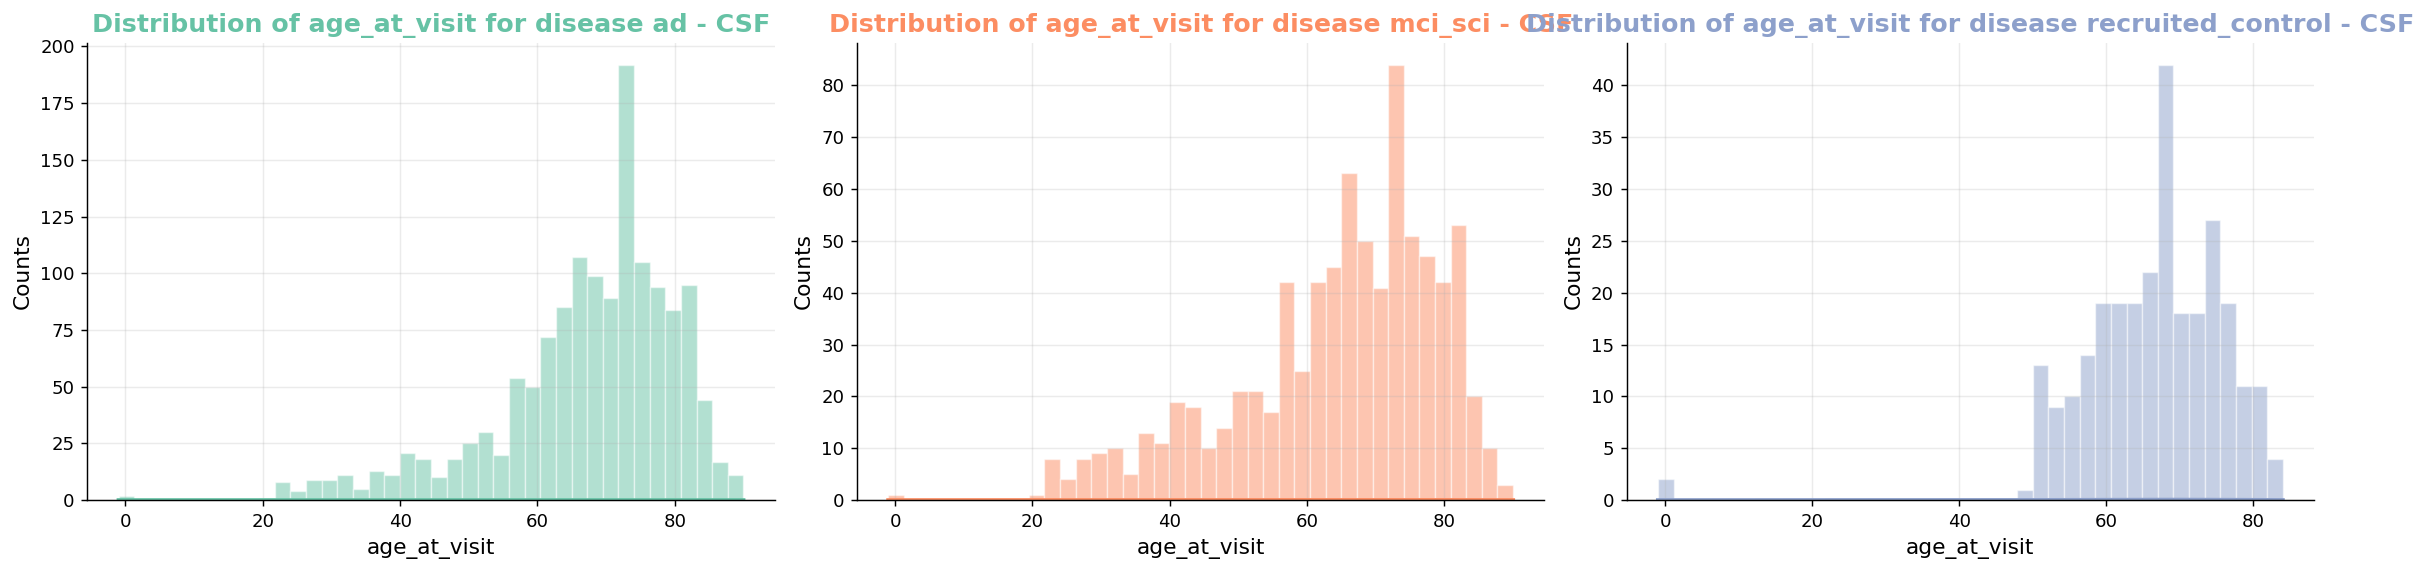

In [97]:
plot_histograms_over_dfs(csf_7k_merged_with_clinical, ['ad', 'mci_sci', 'recruited_control'], 'age_at_visit', disease_status=0, sample_matrix='CSF')

In [79]:
def plot_seq_variance_scatter(df):
    seq_vars = df.filter(regex=r"^seq_").var()

    plt.figure(figsize=(12, 4))
    plt.scatter(range(len(seq_vars)), seq_vars.values, s=5)
    plt.xlabel("Column Index")
    plt.ylabel("Variance")
    plt.title("Variance Across seq_ Columns")
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

# plot_seq_variance_scatter(df)


In [80]:
def plot_top_seq_variances(df, k=20):
    seq_vars = df.filter(regex=r"^seq_").var().sort_values(ascending=False)

    top_vars = seq_vars.head(k)

    plt.figure(figsize=(12, 5))
    plt.bar(top_vars.index, top_vars.values)
    plt.xticks(rotation=90)
    plt.ylabel("Variance")
    plt.title(f"Top {k} Highest Variance seq_ Columns")
    plt.grid(axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

# plot_top_seq_variances(df, k=30)


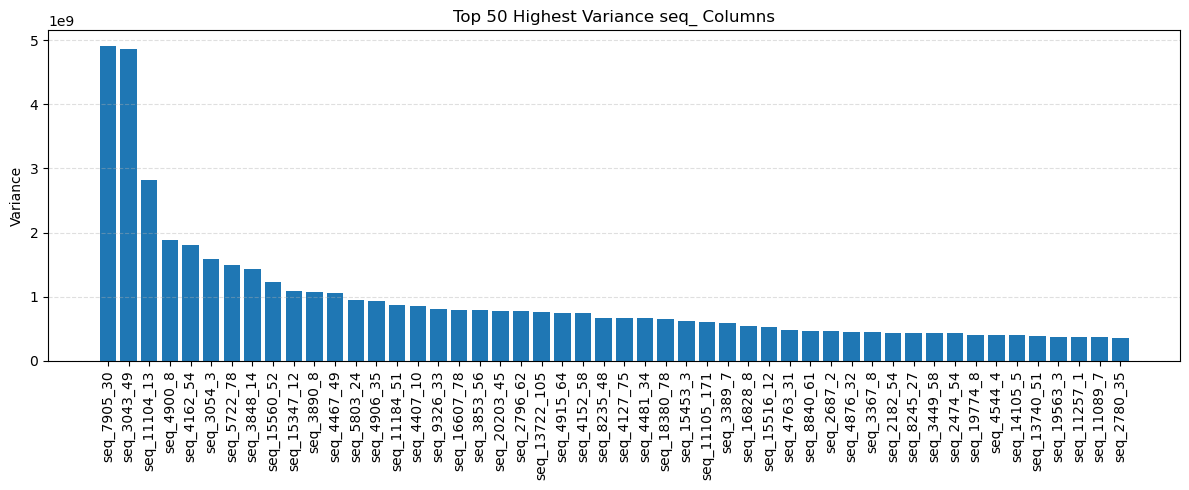

In [81]:
plot_top_seq_variances(csf_7k_merged_with_clinical, k=50)

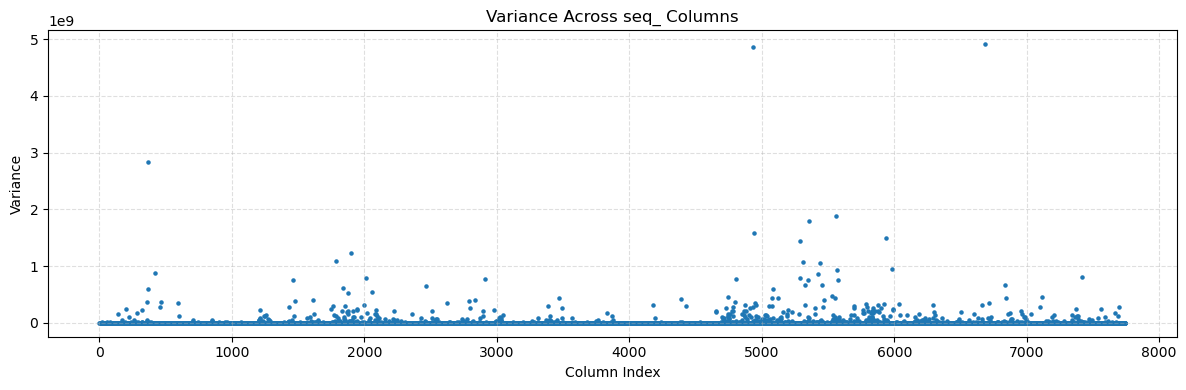

In [82]:
plot_seq_variance_scatter(csf_7k_merged_with_clinical)

In [83]:
def longitudinal_stats(df, mappingData, converter=False, detail=False):
    df = df[df["age_at_visit"] != -1]

    # Merge dfB with dfA to bring person_id into dfB
    df_merged = df.merge(mappingData, on="sample_id", how="inner")

    # Group by person_id and generate list of sub-dataframes
    subdfs = [subdf for _, subdf in df_merged.groupby("person_id")]
    subdfs_multi_visit = [subdf for subdf in subdfs if subdf["sequential_visit_number"].max() > 1 and len(subdf) > 1]
    if converter:
        converted_subdfs_multi_visit = [df for df in subdfs_multi_visit if df["ad"].nunique() > 1 or df["ftd"].nunique() > 1 or df["pd"].nunique() > 1 or df["als"].nunique() > 1 or df["mci_sci"].nunique() > 1 or df["recruited_control"].nunique() > 1]

    print(f"\nTotal unique persons: {len(subdfs)}")
    print(f"Total persons with multiple visits: {len(subdfs_multi_visit)}")
    print(f"Total number of multiple visits: {sum(len(subdf) for subdf in subdfs_multi_visit)}")
    if converter:
        print(f"Total persons with diagnosis changes over visits: {len(converted_subdfs_multi_visit)}")
    if detail:
        for i, subdf in enumerate(subdfs_multi_visit):
            print(f"\nPerson ID: {subdf['person_id'].iloc[0]} - Number of Visits: {len(subdf)}")
            print(subdf[['sample_id', 'sequential_visit_number', 'age_at_visit', 'ad', 'ftd', 'pd', 'als']])


In [84]:
def longitudinal_stats_by_sample_matrix(df, mappingData):
    # Merge dfB with dfA to bring person_id into dfB
    for matrix in ["ad", "ftd", "pd", "als"]:
        print(f"\nLongitudinal stats for disease: {matrix}")
        df_filtered = df[df[matrix] == 1]
        longitudinal_stats(df_filtered, mappingData)

In [85]:
import random

def longitudinal_visual(df, mappingData, analyteInfo, aptamers, vis_n=5, log2_transform=True):
    df = df[df["age_at_visit"] != -1]

    # Merge dfB with dfA to bring person_id into dfB
    df_merged = df.merge(mappingData, on="sample_id", how="inner")

    # Group by person_id and generate list of sub-dataframes
    subdfs = [subdf for _, subdf in df_merged.groupby("person_id")]
    subdfs_multi_visit = [subdf for subdf in subdfs if subdf["sequential_visit_number"].max() > 1 and len(subdf) > 1]    
    if len(subdfs_multi_visit) == 0:
        print("No persons with multiple visits found.")
    else:
        print(f"\nTotal persons with multiple visits: {len(subdfs_multi_visit)}")
        sampled = random.sample(subdfs_multi_visit, min(vis_n, len(subdfs_multi_visit)))
        for df in sampled:
            fig, (ax, ax_leg) = plt.subplots(
                1, 2,
                figsize=(10, 4),
                gridspec_kw={'width_ratios': [4, 1]}  # plot wider than legend
            )
            lines = []
            labels = []
            for aptamer in aptamers:
                d = df[['age_at_visit', aptamer]].dropna().sort_values('age_at_visit')
                if log2_transform:
                    y = np.log2(d[aptamer])
                else:
                    y = d[aptamer]

                line, = ax.plot(
                    d['age_at_visit'], y,
                    '-o',
                    markersize=3,
                    linewidth=1,
                    alpha=0.7,
                    label=analyteInfo[analyteInfo["column_name"] == aptamer]["target"].values[0]
                )

                lines.append(line)
                labels.append(analyteInfo[analyteInfo["column_name"] == aptamer]["target"].values[0])
            # Main plot styling
            ax.set_xlabel('age_at_visit')
            ax.set_ylabel('aptamer value')
            ax.set_title(f'Longitudinal Visualization for Person ID: {df["person_id"].iloc[0]}')

            # Legend panel
            ax_leg.axis('off')  # hide axes
            ax_leg.legend(
                lines,
                labels,
                loc='center left',
                frameon=False
            )
            # plt.tight_layout()
            plt.show()
            plt.close(fig)

        print(f"\nPlotted longitudinal visualizations for {vis_n} persons with multiple visits.")

In [86]:

def age_visual(df_plot, aptamers, analyteInfo, matrix, cohort, vis_n=5, log2_transform=True):

    fig, (ax, ax_leg) = plt.subplots(
        1, 2,
        figsize=(10, 4),
        gridspec_kw={'width_ratios': [4, 1]}  # plot wider than legend
    )
    lines = []
    labels = []
    pseudocount = 1 # small value to avoid log2(0)

    for y in aptamers:

        if log2_transform:
            stats = (
                df_plot
                .groupby("age_at_visit")[y]
                .agg(
                    mean=lambda x: np.log2(x + pseudocount).mean(),
                    std=lambda x: np.log2(x + pseudocount).std()
                )
                .reset_index()
            )
        else:
            stats = (
                df_plot
                .groupby("age_at_visit")[y]
                .agg(["mean", "std"])
                .reset_index()
            )

        line, = ax.plot(
            stats["age_at_visit"], stats["mean"],
            '-o',
            markersize=3,
            linewidth=1,
            alpha=0.7,
            label=analyteInfo[analyteInfo["column_name"] == y]["target"].values[0] if analyteInfo[analyteInfo["column_name"] == y].shape[0] > 0 else y
        )

        # variance band (±1 std)
        ax.fill_between(
            stats["age_at_visit"],
            stats["mean"] - stats["std"],
            stats["mean"] + stats["std"],
            alpha=0.3,
            label="±1 Std"
        )

        lines.append(line)
        labels.append(analyteInfo[analyteInfo["column_name"] == y]["target"].values[0] if analyteInfo[analyteInfo["column_name"] == y].shape[0] > 0 else y)

    # Main plot styling
    ax.set_xlabel('age_at_visit')
    ax.set_ylabel('aptamer value')
    ax.set_title(f'Longitudinal Visualization for {matrix} Samples - Cohort: {cohort}')

    # Legend panel
    ax_leg.axis('off')  # hide axes
    ax_leg.legend(
        lines,
        labels,
        loc='center left',
        frameon=False
    )
    # plt.tight_layout()
    plt.show()
    plt.close(fig)

    print(f"\nPlotted longitudinal visualizations for {vis_n} persons with multiple visits.")

In [87]:
def longitudinal_age_visual(df, mappingData, analyteInfo, matrix, top_k=10, vis_n=5, log2_transform=True):
    df_filtered = df[df[matrix] == 1]
    cohort_spec_dfs = [subdf for _, subdf in df_filtered.groupby("contributor_code")]
    for df in cohort_spec_dfs:
        print(f"Cohort: {df['contributor_code'].iloc[0]} - Number of Samples: {len(df)}")
        seq_vars = df.filter(regex=r"^seq_").var().sort_values(ascending=False)
        top_vars = seq_vars.head(top_k)
        aptamers = top_vars.index.tolist()
        # Merge dfB with dfA to bring person_id into dfB
        df_merged_total = df.merge(mappingData, on="sample_id", how="inner")
        if (len(df) == 0):
            print(f"No samples found after merging with mapping data for cohort {df['contributor_code'].iloc[0]}.")
        else:
            age_visual(df_merged_total, aptamers, analyteInfo, matrix, df['contributor_code'].iloc[0], vis_n=vis_n, log2_transform=log2_transform)


In [88]:
def longitudinal_age_visual_cross_cohort(df, mappingData, analyteInfo, matrix, top_k=10, vis_n=5, log2_transform=True):
    df_filtered = df[df[matrix] == 1]
    seq_vars = df_filtered.filter(regex=r"^seq_").var().sort_values(ascending=False)
    top_vars = seq_vars.head(top_k)
    aptamers = top_vars.index.tolist()
    # Merge dfB with dfA to bring person_id into dfB
    df_merged_total = df_filtered.merge(mappingData, on="sample_id", how="inner")
    age_visual(df_merged_total, aptamers, analyteInfo, matrix, "All Cohorts", vis_n=vis_n, log2_transform=log2_transform)

In [89]:
import random
from matplotlib.lines import Line2D

def longitudinal_visual_converter(df, mappingData, analyteInfo, matrix, top_k=10, vis_n=5, log2_transform=True):
    marker_map = {
        -1: 'x',
        0: 'o',
        1: 's',
    }
    df = df[df["age_at_visit"] != -1]
    seq_vars = df.filter(regex=r"^seq_").var().sort_values(ascending=False)

    top_vars = seq_vars.head(top_k)
    aptamers = top_vars.index.tolist()
    # Merge dfB with dfA to bring person_id into dfB
    df_merged_total = df.merge(mappingData, on="sample_id", how="inner")

    # Group by person_id and generate list of sub-dataframes
    cohort_spec_dfs = [subdf for _, subdf in df_merged_total.groupby("contributor_code")]
    for df_merged in cohort_spec_dfs:
        print(f"\nLongitudinal visualizations for disease stage changes in {matrix} for cohort: {df_merged['contributor_code'].iloc[0]}")
        subdfs = [subdf for _, subdf in df_merged.groupby("person_id")]
        subdfs = [subdf[subdf[matrix] != -1] for subdf in subdfs]  # filter out rows with -1 in the matrix column
        subdfs_multi_visit = [subdf for subdf in subdfs if subdf["sequential_visit_number"].max() > 1 and len(subdf) > 1]  
        # converted_subdfs_multi_visit = [df for df in subdfs_multi_visit if df[matrix].nunique() > 1 and 1 in df[matrix].unique()]  
        converted_subdfs_multi_visit = [df for df in subdfs_multi_visit if 0 in df[matrix].unique() and 1 in df[matrix].unique()]
        if len(converted_subdfs_multi_visit) == 0:
            print(f"No persons with disease stage changes over multiple visits found for {matrix}.")
        else:
            print(f"\nTotal persons with disease stage changes over multiple visits: {len(converted_subdfs_multi_visit)}")
            sampled = random.sample(converted_subdfs_multi_visit, min(vis_n, len(converted_subdfs_multi_visit)))
            for df in sampled:
                fig, (ax, ax_leg) = plt.subplots(
                    1, 2,
                    figsize=(12, 4),
                    gridspec_kw={'width_ratios': [4, 1]},
                    constrained_layout=True
                )

                lines = []
                labels = []
                print(df[["person_id", "sample_id", "age_at_visit", "contributor_code", "sequential_visit_number", matrix]])
                for aptamer in aptamers:
                    d = df[['age_at_visit', aptamer, matrix]].dropna().sort_values('age_at_visit')

                    y = np.log2(d[aptamer]) if log2_transform else d[aptamer]

                    # ---- draw line (NO markers here) ----
                    line, = ax.plot(
                        d['age_at_visit'],
                        y,
                        linewidth=1,
                        alpha=0.7,
                        label= f'{analyteInfo[analyteInfo["column_name"] == aptamer]["target"].values[0]}'
                    )

                    # ---- overlay markers by matrix value ----
                    for z_val, marker in marker_map.items():
                        mask = d[matrix] == z_val
                        ax.scatter(
                            d.loc[mask, 'age_at_visit'],
                            y[mask],
                            marker=marker,
                            s=20,
                            color=line.get_color(),
                            alpha=0.8
                        )

                    lines.append(line)
                    labels.append(analyteInfo[analyteInfo["column_name"] == aptamer]["target"].values[0])

                # ---------------- Main plot styling ----------------
                ax.set_xlabel('age_at_visit')
                ax.set_ylabel('aptamer value')
                ax.set_title(
                    f'Longitudinal Visualization for Person ID: '
                    f'{df["person_id"].iloc[0]} (Disease Stage Changes in {matrix})'
                )

                # ---------------- Legends ----------------
                ax_leg.axis('off')

                # ---- Aptamer legend (top) ----
                aptamer_legend = ax_leg.legend(
                    lines,
                    labels,
                    loc='upper left',
                    bbox_to_anchor=(0.0, 1.0),
                    frameon=False,
                    # title='Aptamer',
                    borderaxespad=0.0
                )

                aptamer_legend._legend_box.align = "left"
                ax_leg.add_artist(aptamer_legend)
                
                # ---- Marker legend (bottom) ----
                marker_handles = [
                    Line2D(
                        [0], [0],
                        marker=marker,
                        linestyle='None',
                        color='black',
                        label=f'{matrix} = {z}',
                        markersize=6
                    )
                    for z, marker in marker_map.items()
                ]

                marker_legend = ax_leg.legend(
                    handles=marker_handles,
                    loc='lower left',
                    bbox_to_anchor=(0.0, 0.0),
                    frameon=False,
                    # title=matrix,
                    borderaxespad=0.0
                )
                
                marker_legend._legend_box.align = "left"
                ax_leg.add_artist(marker_legend)


                # plt.tight_layout()
                plt.show()
                plt.close(fig)

            print(f"\nPlotted longitudinal visualizations for {vis_n} persons with multiple visits (Disease Stage Changes in {matrix}).")

In [90]:
def longitudinal_visual_by_sample_matrix(df, mappingData, analyteInfo, top_k=10, vis_n=5):
    # Merge dfB with dfA to bring person_id into dfB
    for matrix in ["ad", "ftd", "pd", "als"]:
        print(f"\nLongitudinal visualization for sample matrix: {matrix}")
        df_filtered = df[df[matrix] == 1]
        seq_vars = df_filtered.filter(regex=r"^seq_").var().sort_values(ascending=False)

        top_vars = seq_vars.head(top_k)
        longitudinal_visual(df_filtered, mappingData, analyteInfo, aptamers=top_vars.index, vis_n=vis_n)

In [91]:
LILRB4_aptamers = somaAnaly[somaAnaly["target"] == "LILRB4"]
LILRB4_aptamers

,table_name,column_name,apt_name,seq_id,seq_id_version,soma_id,target_full_name,target,uni_prot,entrez_gene_id,entrez_gene_symbol,organism,units,type


In [92]:
somaAnaly

,table_name,column_name,apt_name,seq_id,seq_id_version,soma_id,target_full_name,target,uni_prot,entrez_gene_id,entrez_gene_symbol,organism,units,type
0,Somalogic01V1_4ta,seq_10003_15,seq.10003.15,10003-15,3,SL019245,Zinc finger protein 41,ZNF41,P51814,7592,ZNF41,Human,RFU,Protein
1,Somalogic01V1_4ta,seq_10006_25,seq.10006.25,10006-25,3,SL019228,ETS domain-containing protein Elk-1,ELK1,P19419,2002,ELK1,Human,RFU,Protein
2,Somalogic01V1_4ta,seq_10008_43,seq.10008.43,10008-43,3,SL019234,Guanylyl cyclase-activating protein 1,GUC1A,P43080,2978,GUCA1A,Human,RFU,Protein
3,Somalogic01V1_4ta,seq_10010_10,seq.10010.10,10010-10,3,SL014943,Beclin-1,BECN1,Q14457,8678,BECN1,Human,RFU,Protein
4,Somalogic01V1_4ta,seq_10011_65,seq.10011.65,10011-65,3,SL019246,Inositol polyphosphate 5-phosphatase OCRL-1,OCRL,Q01968,4952,OCRL,Human,RFU,Protein
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7639,Somalogic02V1_4ta,seq_12734_112,seq.12734.112,12734-112,3,SL019869,Kinesin-like protein KIF22,KIF22,Q14807,3835,KIF22,Human,RFU,Protein
7640,Somalogic02V1_4ta,seq_12747_89,seq.12747.89,12747-89,3,SL010231,RNA-binding protein 3,RBM3,P98179,5935,RBM3,Human,RFU,Protein
7641,Somalogic02V1_4ta,seq_12750_9,seq.12750.9,12750-9,3,SL004122,Integrin beta-2,LFA-1 beta-2,P05107,3689,ITGB2,Human,RFU,Protein
7642,Somalogic02V1_4ta,seq_12754_14,seq.12754.14,12754-14,3,SL019899,Cold shock domain-containing protein C2,CSDC2,Q9Y534,27254,CSDC2,Human,RFU,Protein


In [96]:
longitudinal_stats(csf_7k_merged_with_clinical, mappingData, converter=True)
longitudinal_stats_by_sample_matrix(csf_7k_merged_with_clinical, mappingData)
longitudinal_visual_converter(csf_7k_merged_with_clinical, mappingData, somaAnaly, matrix='ad')



Total unique persons: 1912
Total persons with multiple visits: 39
Total number of multiple visits: 78
Total persons with diagnosis changes over visits: 0

Longitudinal stats for disease: ad

Total unique persons: 264
Total persons with multiple visits: 0
Total number of multiple visits: 0

Longitudinal stats for disease: ftd

Total unique persons: 84
Total persons with multiple visits: 0
Total number of multiple visits: 0

Longitudinal stats for disease: pd

Total unique persons: 295
Total persons with multiple visits: 39
Total number of multiple visits: 78

Longitudinal stats for disease: als

Total unique persons: 6
Total persons with multiple visits: 0
Total number of multiple visits: 0

Longitudinal visualizations for disease stage changes in ad for cohort: N
No persons with disease stage changes over multiple visits found for ad.

Longitudinal visualizations for disease stage changes in ad for cohort: Q
No persons with disease stage changes over multiple visits found for ad.

Lon